# 07 · Costo-efectividad de la llamada del día siguiente

**Pregunta de negocio:** si cada día llamamos a una parte de las citas de mañana, ¿cuánto dinero recuperamos, cuánto nos cuesta y a quién conviene llamar primero?

### La lógica financiera, en sencillo
Para cada cita de mañana el modelo da una probabilidad de inasistencia $p$. Si llamamos a ese paciente:

| Concepto | Fórmula | Ejemplo (p = 0,40, cupo de $45.000, efectividad 25 %, llamada de $2.500) |
|---|---|---|
| Inasistencias evitadas (esperadas) | $p \times \text{efectividad}$ | 0,40 × 0,25 = 0,10 cupos |
| Valor recuperado esperado | $p \times \text{efectividad} \times \text{valor del cupo}$ | 0,10 × 45.000 = $4.500 |
| **Beneficio neto esperado** | valor recuperado − costo de la llamada | 4.500 − 2.500 = **$2.000** |

- **Conviene llamar** si el beneficio neto esperado es positivo.
- **Umbral de equilibrio** del servicio: $p^* = \dfrac{\text{costo llamada}}{\text{efectividad} \times \text{valor del cupo}}$. Por debajo de ese riesgo, la llamada cuesta más de lo que recupera.
- Como **cada servicio tiene un valor distinto**, una cita de riesgo medio en un servicio costoso puede valer más que una de riesgo alto en uno barato. Por eso comparamos dos formas de priorizar:
  1. **Por riesgo** ($p$): la lista actual de la herramienta diaria.
  2. **Por impacto financiero** ($p \times \text{efectividad} \times \text{valor}$): el dinero esperado en juego.

### Dónde se editan los parámetros
| Archivo | Qué contiene |
|---|---|
| `modelos/config_negocio.json` | Capacidad de llamadas (principal y ampliada), costo de la llamada, efectividad general y valor general del cupo (se usa si un servicio no tiene valor propio) |
| `modelos/costos_por_servicio.xlsx` | **Valor del cupo por servicio** (y efectividad por servicio, opcional). Celdas amarillas |

Después de modificarlos, vuelva a ejecutar todo el notebook (*Run All*). Todas las cifras se recalculan.

> ⚠️ **Todos los resultados monetarios dependen de supuestos** (valor del cupo, costo y efectividad de la llamada). Son estimaciones para decidir, no cifras contables. La efectividad real solo se conoce con un piloto controlado.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import funciones_inasistencia as fi
import funciones_modelado as fm

pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 200)
fm.estilo_graficos()

import json
from pathlib import Path
import joblib

def pesos(valor):
    # Formato de moneda colombiana: $1.234.567
    signo = "-" if valor < 0 else ""
    return f"{signo}${abs(valor):,.0f}".replace(",", ".")

## 1. Parámetros generales (`config_negocio.json`)

In [2]:
with open("modelos/config_negocio.json", encoding="utf-8") as archivo:
    negocio = json.load(archivo)

CAPACIDAD_PRINCIPAL = negocio["CAPACIDAD_PRINCIPAL"]   # % de citas del día que se pueden llamar
CAPACIDAD_AMPLIADA = negocio["CAPACIDAD_AMPLIADA"]     # escenario con mensajes automáticos
COSTO_LLAMADA = negocio["COSTO_LLAMADA"]               # pesos por llamada
EFECTIVIDAD_GENERAL = negocio["EFECTIVIDAD_LLAMADA"]   # fracción de inasistencias que la llamada evita
VALOR_CUPO_GENERAL = negocio["COSTO_CUPO_PERDIDO"]     # valor por defecto si el servicio no tiene uno propio

# Supuesto para proyectar a un mes: días con atención por mes (lunes a sábado, sin festivos). Editable.
DIAS_ATENCION_MES = 24

# El umbral es un valor DERIVADO: se recalcula y se guarda para que el archivo quede coherente
negocio["UMBRAL_COSTO_BENEFICIO"] = COSTO_LLAMADA / (EFECTIVIDAD_GENERAL * VALOR_CUPO_GENERAL)
with open("modelos/config_negocio.json", "w", encoding="utf-8") as archivo:
    json.dump(negocio, archivo, indent=2)

pd.Series({
    "Capacidad principal": f"{CAPACIDAD_PRINCIPAL:.0%} de las citas del día",
    "Capacidad ampliada": f"{CAPACIDAD_AMPLIADA:.0%} de las citas del día",
    "Costo por llamada": pesos(COSTO_LLAMADA),
    "Efectividad general de la llamada": f"{EFECTIVIDAD_GENERAL:.0%}",
    "Días de atención por mes (proyección)": DIAS_ATENCION_MES,
    "Valor general del cupo (por defecto)": pesos(VALOR_CUPO_GENERAL),
    "Umbral general de equilibrio (p*)": f"{negocio['UMBRAL_COSTO_BENEFICIO']:.2f}",
}, name="valor").to_frame()

,valor
Capacidad principal,10% de las citas del día
Capacidad ampliada,30% de las citas del día
Costo por llamada,$2.500
Efectividad general de la llamada,25%
Días de atención por mes (proyección),24
Valor general del cupo (por defecto),$45.000
Umbral general de equilibrio (p*),0.22


## 2. Valor del cupo por servicio (`costos_por_servicio.xlsx`)

Para cada servicio se toma el valor que usted escribió. Si la celda está vacía, se usa el valor general. Lo mismo con la efectividad.

In [3]:
costos = pd.read_excel("modelos/costos_por_servicio.xlsx", sheet_name="costos")

costos["valor_propio"] = costos["valor_cupo_COP"].notna()
costos["valor_cupo"] = costos["valor_cupo_COP"].fillna(VALOR_CUPO_GENERAL).astype(float)
costos["efectividad"] = costos["efectividad_llamada"].fillna(EFECTIVIDAD_GENERAL).astype(float)

# Umbral de equilibrio por servicio: riesgo mínimo para que la llamada se pague sola
costos["umbral_equilibrio"] = COSTO_LLAMADA / (costos["efectividad"] * costos["valor_cupo"])

n_propios = int(costos["valor_propio"].sum())
print(f"Servicios con valor propio: {n_propios} de {len(costos)}")
if n_propios == 0:
    print("⚠️ Todavía no hay valores por servicio: todos usan el valor general. Complete la columna amarilla del Excel.")

vista = costos[["servicio_homologado", "familia_servicio", "citas_promedio_mes", "tasa_inasistencia_historica",
                "valor_cupo", "valor_propio", "efectividad", "umbral_equilibrio"]].copy()
vista["valor_cupo"] = vista["valor_cupo"].apply(pesos)
vista.round(3)

Servicios con valor propio: 45 de 45


,servicio_homologado,familia_servicio,citas_promedio_mes,tasa_inasistencia_historica,valor_cupo,valor_propio,efectividad,umbral_equilibrio
0,MEDICINA GENERAL,Medicina general,13284,0.301,$14.500,True,0.25,0.690
1,CRONICOS - MEDICO,Crónicos,7429,0.240,$14.500,True,0.25,0.690
2,ODONTOLOGIA,Odontología,5697,0.367,$12.500,True,0.25,0.800
3,PSICOLOGIA,Salud mental,1819,0.433,$12.500,True,0.25,0.800
4,NUTRICIONISTA,Nutrición,1437,0.422,$12.500,True,0.25,0.800
5,MEDICINA INTERNA,Especialista,1360,0.291,$28.000,True,0.25,0.357
6,PEDIATRIA,Pediatría,1032,0.310,$28.000,True,0.25,0.357
7,GINECOLOGIA Y OBSTETRICIA,Especialista,918,0.352,$30.000,True,0.25,0.333
8,ORTOPEDIA Y TRAUMATOLOGIA,Especialista,683,0.297,$37.000,True,0.25,0.270
9,PYP CURSO DE VIDA - ENFERMERIA,Enfermería / PyP,615,0.400,$5.000,True,0.25,2.000


**Cómo leer el umbral de equilibrio:** si el umbral de un servicio es 0,50, solo vale la pena llamar a citas de ese servicio con más de 50 % de riesgo. Si un servicio tiene un umbral mayor que 1, **ninguna llamada se paga sola** con ese valor de cupo, costo y efectividad.

## 3. Datos de evaluación: producción simulada (agosto–septiembre)

Usamos el **modelo de producción** (entrenado hasta julio) sobre agosto y septiembre, citas que el modelo **nunca vio**. Así simulamos lo que habría pasado si la herramienta hubiera estado operando.

Para cada cita calculamos:
- `p`: probabilidad de inasistencia (modelo)
- `valor_esperado = p × efectividad × valor_cupo`
- `beneficio_esperado = valor_esperado − costo_llamada`

In [4]:
paquete = joblib.load("modelos/modelo_inasistencia.joblib")
dataset = pd.read_parquet("dataset_modelo_v2.parquet")
citas = dataset[dataset["particion"] == "produccion_simulada"].copy()

citas["p"] = paquete["modelo"].predict_proba(citas[paquete["variables"]])[:, 1]
citas = citas.merge(costos[["servicio_homologado", "valor_cupo", "efectividad"]], on="servicio_homologado", how="left")
citas["valor_cupo"] = citas["valor_cupo"].fillna(VALOR_CUPO_GENERAL)
citas["efectividad"] = citas["efectividad"].fillna(EFECTIVIDAD_GENERAL)

citas["valor_esperado"] = citas["p"] * citas["efectividad"] * citas["valor_cupo"]
citas["beneficio_esperado"] = citas["valor_esperado"] - COSTO_LLAMADA

dias = citas["fecha_cita"].nunique()
print(f"Periodo: {citas['fecha_cita'].min().date()} a {citas['fecha_cita'].max().date()} | {dias} días con citas | {len(citas):,} citas")
print(f"Inasistencia real: {citas['no_asiste'].mean():.1%} | predicha: {citas['p'].mean():.1%}")
print(f"Valor en riesgo (inasistencias reales × valor del cupo): {pesos((citas['no_asiste'] * citas['valor_cupo']).sum())}")

Periodo: 2026-08-01 a 2026-09-11 | 32 días con citas | 46,106 citas
Inasistencia real: 30.6% | predicha: 30.3%
Valor en riesgo (inasistencias reales × valor del cupo): $221.506.500


## 4. Simulación de estrategias de llamada

Cada día se llama a una fracción de las citas (la capacidad). Comparamos **a quién** llamar:

| Estrategia | Criterio para escoger las llamadas del día |
|---|---|
| Azar | Citas al azar (referencia: lo que se lograría sin modelo) |
| Por riesgo | Mayor probabilidad de inasistencia $p$ |
| Por impacto financiero | Mayor valor esperado $p \times \text{efectividad} \times \text{valor}$ |

**Resultado financiero real** (con lo que realmente pasó): si llamamos a un paciente que **sí iba a faltar**, la llamada evita la inasistencia con probabilidad igual a la efectividad y recuperamos el valor del cupo. Si llamamos a alguien que iba a asistir, solo gastamos la llamada.

- Cupos recuperados = Σ (faltó × efectividad) de las citas llamadas
- Valor recuperado = Σ (faltó × efectividad × valor del cupo)
- Costo = número de llamadas × costo por llamada
- **Beneficio neto** = valor recuperado − costo
- **ROI** = beneficio neto ÷ costo (por cada peso invertido, cuánto se gana)
- **Costo por cupo recuperado** = costo ÷ cupos recuperados

In [5]:
def seleccionar_llamadas(df, capacidad, criterio, semilla=42):
    # Marca con 1 las citas que se llaman cada día según el criterio y la capacidad
    if criterio == "azar":
        puntaje = pd.Series(np.random.default_rng(semilla).random(len(df)), index=df.index)
    elif criterio == "riesgo":
        puntaje = df["p"]
    elif criterio == "impacto":
        puntaje = df["valor_esperado"]
    rango = puntaje.groupby(df["fecha_cita"]).rank(method="first", ascending=False, pct=True)
    return (rango <= capacidad).astype(int)


def resultado_financiero(df, llamada):
    # Resultado con lo que realmente ocurrió (no_asiste) en las citas llamadas
    llamadas = df[llamada == 1]
    cupos = (llamadas["no_asiste"] * llamadas["efectividad"]).sum()
    valor = (llamadas["no_asiste"] * llamadas["efectividad"] * llamadas["valor_cupo"]).sum()
    costo = len(llamadas) * COSTO_LLAMADA
    return {
        "llamadas": len(llamadas),
        "llamadas_por_dia": len(llamadas) / df["fecha_cita"].nunique(),
        "precision": llamadas["no_asiste"].mean() if len(llamadas) else 0.0,
        "cupos_recuperados": cupos,
        "valor_recuperado": valor,
        "costo": costo,
        "beneficio_neto": valor - costo,
        "ROI": (valor - costo) / costo if costo else 0.0,
        "costo_por_cupo_recuperado": costo / cupos if cupos else np.nan,
    }


filas = []
for capacidad in [CAPACIDAD_PRINCIPAL, CAPACIDAD_AMPLIADA]:
    for criterio in ["azar", "riesgo", "impacto"]:
        fila = resultado_financiero(citas, seleccionar_llamadas(citas, capacidad, criterio))
        fila.update({"capacidad": f"{capacidad:.0%}", "estrategia": criterio})
        filas.append(fila)

# Referencia sin límite de capacidad: llamar a TODAS las citas con beneficio esperado positivo
rentables = (citas["beneficio_esperado"] > 0).astype(int)
fila = resultado_financiero(citas, rentables)
fila.update({"capacidad": f"sin límite ({rentables.mean():.0%})", "estrategia": "todas las rentables"})
filas.append(fila)

estrategias = pd.DataFrame(filas).set_index(["capacidad", "estrategia"])
tabla = estrategias.copy()
for columna in ["valor_recuperado", "costo", "beneficio_neto", "costo_por_cupo_recuperado"]:
    tabla[columna] = tabla[columna].apply(lambda v: pesos(v) if pd.notna(v) else "—")
tabla["precision"] = tabla["precision"].map("{:.1%}".format)
tabla["ROI"] = tabla["ROI"].map("{:.2f}".format)
tabla["llamadas_por_dia"] = tabla["llamadas_por_dia"].round(0).astype(int)
tabla["cupos_recuperados"] = tabla["cupos_recuperados"].round(0).astype(int)
tabla

llamadas  llamadas_por_dia precision  cupos_recuperados valor_recuperado        costo beneficio_neto    ROI costo_por_cupo_recuperado
capacidad       estrategia                                                                                                                                                
10%             azar                     4597               144     29.6%                341       $5.406.550  $11.492.500    -$6.085.950  -0.53                   $33.727
                riesgo                   4597               144     59.7%                686       $9.679.100  $11.492.500    -$1.813.400  -0.16                   $16.741
                impacto                  4597               144     42.9%                493      $11.940.800  $11.492.500       $448.300   0.04                   $23.311
30%             azar                    13818               432     30.4%               1050      $16.530.875  $34.545.000   -$18.014.125  -0.52                   $32.900
                riesgo                  13818               432     48.3%               1668      $23.897.375  $34.545.000   -$10.647.625  -0.31                   $20.707
                impacto                 13818               432     41.4%               1430      $27.120.175  $34.545.000    -$7.424.825  -0.21                   $24.166
sin límite (5%) todas las rentables      2430                76     41.3%                251       $7.434.700   $6.075.000     $1.359.700   0.22                   $24.227

In [6]:
# Conclusiones calculadas (se actualizan con los parámetros)
# Proyección mensual = beneficio promedio por día con citas × días de atención al mes (supuesto)
for capacidad in [CAPACIDAD_PRINCIPAL, CAPACIDAD_AMPLIADA]:
    c = f"{capacidad:.0%}"
    azar = estrategias.loc[(c, "azar")]
    riesgo = estrategias.loc[(c, "riesgo")]
    impacto = estrategias.loc[(c, "impacto")]
    print(f"Capacidad {c} (~{riesgo['llamadas_por_dia']:.0f} llamadas/día):")
    print(f"  Beneficio neto — azar: {pesos(azar['beneficio_neto'])} | por riesgo: {pesos(riesgo['beneficio_neto'])} | "
          f"por impacto: {pesos(impacto['beneficio_neto'])}  (periodo de {dias} días)")
    print(f"  Proyección mensual por impacto ({DIAS_ATENCION_MES} días de atención): "
          f"{pesos(impacto['beneficio_neto'] / dias * DIAS_ATENCION_MES)} | ROI {impacto['ROI']:.2f} | "
          f"costo por cupo recuperado {pesos(impacto['costo_por_cupo_recuperado'])}")
    print(f"  Valor agregado por el modelo frente al azar: {pesos(impacto['beneficio_neto'] - azar['beneficio_neto'])}\n")

Capacidad 10% (~144 llamadas/día):
  Beneficio neto — azar: -$6.085.950 | por riesgo: -$1.813.400 | por impacto: $448.300  (periodo de 32 días)
  Proyección mensual por impacto (24 días de atención): $336.225 | ROI 0.04 | costo por cupo recuperado $23.311
  Valor agregado por el modelo frente al azar: $6.534.250

Capacidad 30% (~432 llamadas/día):
  Beneficio neto — azar: -$18.014.125 | por riesgo: -$10.647.625 | por impacto: -$7.424.825  (periodo de 32 días)
  Proyección mensual por impacto (24 días de atención): -$5.568.619 | ROI -0.21 | costo por cupo recuperado $24.166
  Valor agregado por el modelo frente al azar: $10.589.300



**Cómo leer:**
- Si el **beneficio neto por azar es negativo** y el del modelo es positivo, el modelo es lo que hace rentable la estrategia de llamadas.
- Si todos los valores del cupo son iguales (plantilla sin diligenciar), "por riesgo" y "por impacto" dan casi lo mismo. Las diferencias aparecen cuando los servicios tienen valores distintos.
- "Todas las rentables" muestra cuántas llamadas serían económicamente justificables si no hubiera límite de capacidad.

## 5. ¿Cuántas llamadas al día conviene hacer?
Recorremos capacidades del 2 % al 100 % y medimos el beneficio neto. El punto más alto de la curva es la **capacidad óptima** con los parámetros actuales.

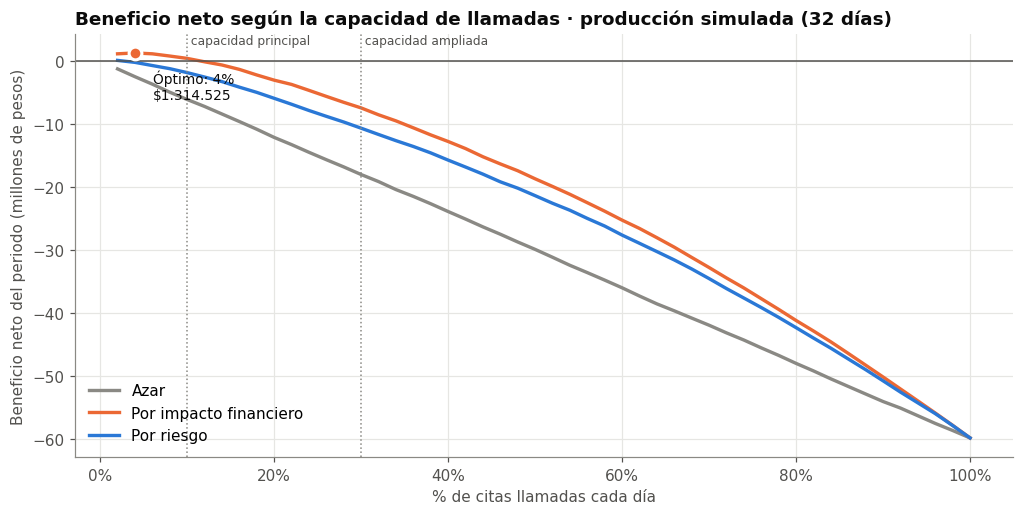

Capacidad óptima (por impacto): 4% de las citas diarias (~57 llamadas/día) → beneficio neto $1.314.525, ROI 0.29


In [7]:
capacidades = np.round(np.arange(0.02, 1.001, 0.02), 2)
curvas = []
for capacidad in capacidades:
    for criterio in ["azar", "riesgo", "impacto"]:
        r = resultado_financiero(citas, seleccionar_llamadas(citas, capacidad, criterio))
        curvas.append({"capacidad": capacidad, "estrategia": criterio, **r})
curvas = pd.DataFrame(curvas)

colores = {"azar": fm.GRIS, "riesgo": fm.AZUL, "impacto": fm.NARANJA}
nombres = {"azar": "Azar", "riesgo": "Por riesgo", "impacto": "Por impacto financiero"}
fig, ax = plt.subplots(figsize=(11, 5))
for criterio, datos in curvas.groupby("estrategia"):
    ax.plot(datos["capacidad"], datos["beneficio_neto"] / 1e6, color=colores[criterio], linewidth=2.2, label=nombres[criterio])
ax.axhline(0, color=fm.TINTA_SUAVE, linewidth=1)
for capacidad, texto in [(CAPACIDAD_PRINCIPAL, "principal"), (CAPACIDAD_AMPLIADA, "ampliada")]:
    ax.axvline(capacidad, color=fm.GRIS, linestyle=":", linewidth=1)
    ax.text(capacidad, ax.get_ylim()[1], f" capacidad {texto}", fontsize=8, color=fm.TINTA_SUAVE, va="top")
optimo = curvas[curvas["estrategia"] == "impacto"].sort_values("beneficio_neto").iloc[-1]
ax.scatter([optimo["capacidad"]], [optimo["beneficio_neto"] / 1e6], s=70, color=fm.NARANJA, zorder=5, edgecolor="white", linewidth=2)
ax.annotate(f"Óptimo: {optimo['capacidad']:.0%}\n{pesos(optimo['beneficio_neto'])}", (optimo["capacidad"], optimo["beneficio_neto"] / 1e6),
            xytext=(12, -30), textcoords="offset points", fontsize=9, color=fm.TINTA)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))
ax.set_xlabel("% de citas llamadas cada día")
ax.set_ylabel("Beneficio neto del periodo (millones de pesos)")
ax.set_title(f"Beneficio neto según la capacidad de llamadas · producción simulada ({dias} días)")
ax.legend(loc="lower left")
plt.show()

print(f"Capacidad óptima (por impacto): {optimo['capacidad']:.0%} de las citas diarias "
      f"(~{optimo['llamadas_por_dia']:.0f} llamadas/día) → beneficio neto {pesos(optimo['beneficio_neto'])}, ROI {optimo['ROI']:.2f}")

**Interpretación:** la curva sube mientras las llamadas adicionales recuperan más de lo que cuestan y baja cuando se empieza a llamar a citas de bajo riesgo (o bajo valor). Si el óptimo está muy por encima de la capacidad actual, **ampliar el canal** (por ejemplo, mensajes automáticos, más baratos) tiene sentido económico.

## 6. Resultado por servicio (estrategia por impacto, capacidad principal)

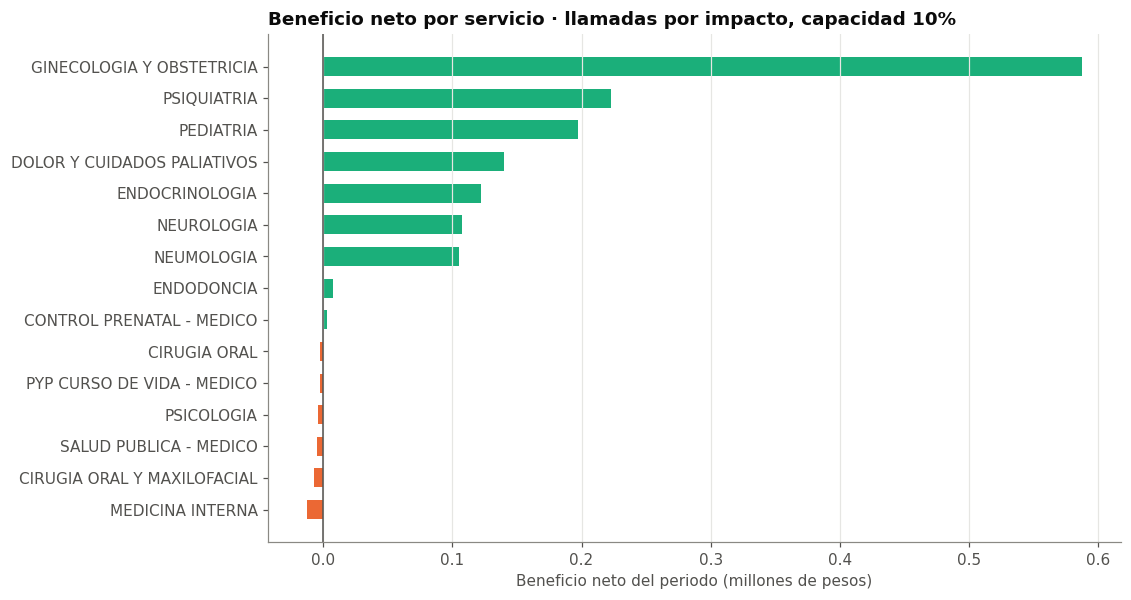

,servicio,citas,valor_cupo,llamadas,%_citas_llamadas,precision,cupos_recuperados,valor_recuperado,costo,beneficio_neto
13,GINECOLOGIA Y OBSTETRICIA,972,$30.000,527,54.2%,48.2%,63.5,$1.905.000,$1.317.500,$587.500
28,PSIQUIATRIA,572,$30.000,310,54.2%,42.9%,33.2,$997.500,$775.000,$222.500
24,PEDIATRIA,1052,$28.000,456,43.3%,41.9%,47.8,$1.337.000,$1.140.000,$197.000
10,DOLOR Y CUIDADOS PALIATIVOS,115,$60.000,100,87.0%,26.0%,6.5,$390.000,$250.000,$140.000
11,ENDOCRINOLOGIA,238,$50.000,226,95.0%,24.3%,13.8,$687.500,$565.000,$122.500
20,NEUROLOGIA,306,$50.000,217,70.9%,24.0%,13.0,$650.000,$542.500,$107.500
19,NEUMOLOGIA,291,$45.000,75,25.8%,34.7%,6.5,$292.500,$187.500,$105.000
12,ENDODONCIA,168,$30.000,15,8.9%,40.0%,1.5,$45.000,$37.500,$7.500
4,CONTROL PRENATAL - MEDICO,366,$14.200,3,0.8%,100.0%,0.8,$10.650,$7.500,$3.150
26,PROMOCION Y PREVENCION - ENFERMERIA,569,$5.000,0,0.0%,0.0%,0.0,$0,$0,$0


In [8]:
llamada = seleccionar_llamadas(citas, CAPACIDAD_PRINCIPAL, "impacto")
filas = []
for servicio, grupo in citas.groupby("servicio_homologado"):
    r = resultado_financiero(grupo, llamada.loc[grupo.index])
    filas.append({"servicio": servicio, "citas": len(grupo), "valor_cupo": grupo["valor_cupo"].iloc[0], **r})
por_servicio = pd.DataFrame(filas).sort_values("beneficio_neto", ascending=False)
por_servicio["%_citas_llamadas"] = por_servicio["llamadas"] / por_servicio["citas"]

top = por_servicio[por_servicio["llamadas"] > 0].head(15)
fig, ax = plt.subplots(figsize=(10, 6))
colores_barras = [fm.AQUA if v >= 0 else fm.NARANJA for v in top["beneficio_neto"]]
ax.barh(top["servicio"], top["beneficio_neto"] / 1e6, color=colores_barras, height=0.6)
ax.axvline(0, color=fm.TINTA_SUAVE, linewidth=1)
ax.invert_yaxis()
ax.set_xlabel("Beneficio neto del periodo (millones de pesos)")
ax.set_title(f"Beneficio neto por servicio · llamadas por impacto, capacidad {CAPACIDAD_PRINCIPAL:.0%}")
ax.grid(axis="y", visible=False)
plt.show()

vista = por_servicio[["servicio", "citas", "valor_cupo", "llamadas", "%_citas_llamadas", "precision", "cupos_recuperados",
                      "valor_recuperado", "costo", "beneficio_neto"]].copy()
for columna in ["valor_cupo", "valor_recuperado", "costo", "beneficio_neto"]:
    vista[columna] = vista[columna].apply(pesos)
vista["%_citas_llamadas"] = vista["%_citas_llamadas"].map("{:.1%}".format)
vista["precision"] = vista["precision"].map("{:.1%}".format)
vista["cupos_recuperados"] = vista["cupos_recuperados"].round(1)
vista

## 7. Análisis de sensibilidad

Los supuestos más inciertos son la **efectividad** y el **costo** de la llamada. El mapa muestra el beneficio neto del periodo (estrategia por impacto, capacidad principal) para distintas combinaciones:
- **Azul:** gana dinero.
- **Rojo:** pierde dinero.
- **Recuadro:** los valores actuales.

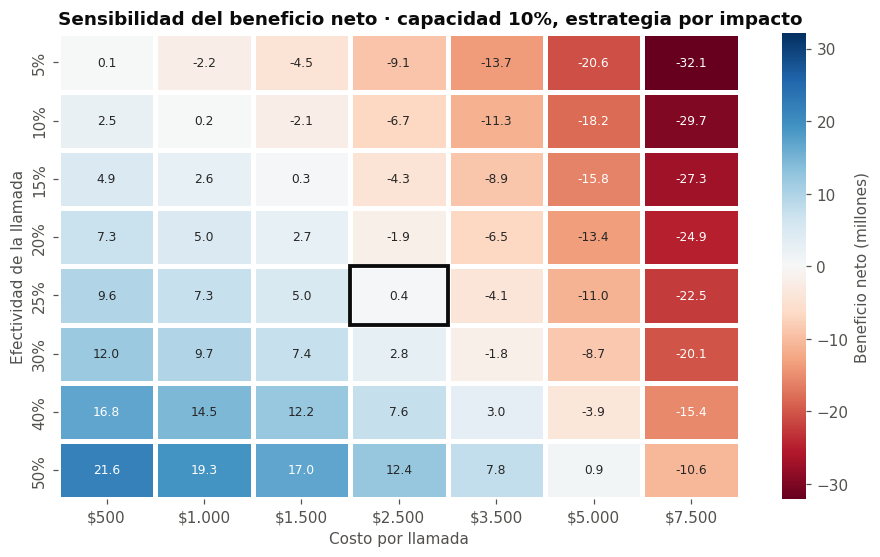

In [9]:
def beneficio_con(efectividad_factor=1.0, costo_llamada=COSTO_LLAMADA, factor_valor=1.0, capacidad=CAPACIDAD_PRINCIPAL):
    # Recalcula todo con parámetros alternativos (la efectividad se escala proporcionalmente por servicio)
    df = citas.copy()
    df["efectividad"] = (df["efectividad"] * efectividad_factor).clip(upper=1)
    df["valor_cupo"] = df["valor_cupo"] * factor_valor
    df["valor_esperado"] = df["p"] * df["efectividad"] * df["valor_cupo"]
    marca = seleccionar_llamadas(df, capacidad, "impacto")
    llamadas = df[marca == 1]
    valor = (llamadas["no_asiste"] * llamadas["efectividad"] * llamadas["valor_cupo"]).sum()
    return valor - len(llamadas) * costo_llamada

efectividades = [0.05, 0.10, 0.15, 0.20, 0.25, 0.30, 0.40, 0.50]
costos_llamada = [500, 1000, 1500, 2500, 3500, 5000, 7500]
matriz = pd.DataFrame(
    [[beneficio_con(e / EFECTIVIDAD_GENERAL, c) / 1e6 for c in costos_llamada] for e in efectividades],
    index=[f"{e:.0%}" for e in efectividades], columns=[pesos(c) for c in costos_llamada])

fig, ax = plt.subplots(figsize=(10, 5.5))
limite = np.abs(matriz.values).max()
sns.heatmap(matriz, cmap="RdBu", center=0, vmin=-limite, vmax=limite, annot=True, fmt=".1f", ax=ax,
            linewidths=2, linecolor="white", cbar_kws={"label": "Beneficio neto (millones)"}, annot_kws={"fontsize": 8})
if EFECTIVIDAD_GENERAL in efectividades and COSTO_LLAMADA in costos_llamada:
    fila, columna = efectividades.index(EFECTIVIDAD_GENERAL), costos_llamada.index(COSTO_LLAMADA)
    ax.add_patch(plt.Rectangle((columna, fila), 1, 1, fill=False, edgecolor=fm.TINTA, linewidth=2.5))
ax.grid(False)
ax.set_xlabel("Costo por llamada")
ax.set_ylabel("Efectividad de la llamada")
ax.set_title(f"Sensibilidad del beneficio neto · capacidad {CAPACIDAD_PRINCIPAL:.0%}, estrategia por impacto")
plt.show()

In [10]:
# Sensibilidad al valor del cupo: ¿qué pasa si los valores reales son 50 % menores o mayores?
filas = []
for factor in [0.5, 0.75, 1.0, 1.25, 1.5, 2.0]:
    filas.append({"valor del cupo": f"{factor:.0%} del actual",
                  f"beneficio neto (capacidad {CAPACIDAD_PRINCIPAL:.0%})": pesos(beneficio_con(factor_valor=factor)),
                  f"beneficio neto (capacidad {CAPACIDAD_AMPLIADA:.0%})": pesos(beneficio_con(factor_valor=factor, capacidad=CAPACIDAD_AMPLIADA))})
pd.DataFrame(filas)

,valor del cupo,beneficio neto (capacidad 10%),beneficio neto (capacidad 30%)
0,50% del actual,-$5.522.100,-$20.984.912
1,75% del actual,-$2.536.900,-$14.204.869
2,100% del actual,$448.300,-$7.424.825
3,125% del actual,$3.433.500,-$644.781
4,150% del actual,$6.418.700,$6.135.262
5,200% del actual,$12.389.100,$19.695.350


In [11]:
# Punto de equilibrio de la efectividad: efectividad mínima para que la estrategia no pierda dinero
from scipy.optimize import brentq
funcion = lambda e: beneficio_con(e / EFECTIVIDAD_GENERAL)
if funcion(0.001) < 0 < funcion(1.0):
    equilibrio = brentq(funcion, 0.001, 1.0)
    print(f"Con los valores actuales, la estrategia es rentable si la llamada evita al menos el {equilibrio:.1%} de las inasistencias "
          f"de los pacientes llamados (capacidad {CAPACIDAD_PRINCIPAL:.0%}, por impacto).")
elif funcion(0.001) >= 0:
    print("La estrategia es rentable incluso con una efectividad casi nula.")
else:
    print("Con los valores actuales la estrategia no es rentable ni con efectividad del 100 %.")

Con los valores actuales, la estrategia es rentable si la llamada evita al menos el 24.1% de las inasistencias de los pacientes llamados (capacidad 10%, por impacto).


## 8. La llamada del día siguiente: lista priorizada por impacto financiero

Esta sección hace lo mismo que la herramienta diaria (`prediccion_diaria.py`), pero agrega el análisis financiero:
1. Predice el riesgo de cada cita de la fecha elegida, usando solo la información disponible el día anterior.
2. Le asigna el valor del cupo de su servicio.
3. Ordena por **beneficio esperado** y marca las llamadas que caben en la capacidad **y** son rentables.
4. Muestra la curva de beneficio acumulado del día y exporta el Excel.

Cambie `FECHA_LLAMADAS` por la fecha de las citas de mañana.

In [12]:
FECHA_LLAMADAS = "2026-08-27"   # <- fecha de las citas (normalmente, mañana)

import prediccion_diaria as pdiaria
fuentes = fi.cargar_fuentes(".")
manana, no_evaluadas = pdiaria.predecir_citas(FECHA_LLAMADAS, ".", paquete, fuentes)

manana = manana.merge(costos[["servicio_homologado", "valor_cupo", "efectividad"]], on="servicio_homologado", how="left")
manana["valor_cupo"] = manana["valor_cupo"].fillna(VALOR_CUPO_GENERAL)
manana["efectividad"] = manana["efectividad"].fillna(EFECTIVIDAD_GENERAL)
manana["valor_esperado"] = manana["probabilidad_inasistencia"] * manana["efectividad"] * manana["valor_cupo"]
manana["beneficio_esperado"] = manana["valor_esperado"] - COSTO_LLAMADA

manana = manana.sort_values("beneficio_esperado", ascending=False).reset_index(drop=True)
manana["prioridad_financiera"] = np.arange(1, len(manana) + 1)
cupo_llamadas = int(round(CAPACIDAD_PRINCIPAL * len(manana)))
manana["llamar"] = np.where((manana["prioridad_financiera"] <= cupo_llamadas) & (manana["beneficio_esperado"] > 0), "Sí", "No")
manana["beneficio_acumulado"] = manana["beneficio_esperado"].cumsum()

llamar = manana[manana["llamar"] == "Sí"]
print(f"Citas evaluadas el {FECHA_LLAMADAS}: {len(manana)} | capacidad: {cupo_llamadas} llamadas | "
      f"llamadas recomendadas (rentables dentro de la capacidad): {len(llamar)}")
print(f"Beneficio neto esperado del día: {pesos(llamar['beneficio_esperado'].sum())} | costo: {pesos(len(llamar) * COSTO_LLAMADA)} | "
      f"valor esperado recuperado: {pesos(llamar['valor_esperado'].sum())}")
print(f"Citas rentables fuera de la capacidad: {int(((manana['beneficio_esperado'] > 0) & (manana['llamar'] == 'No')).sum())}")

Citas evaluadas el 2026-08-27: 1834 | capacidad: 183 llamadas | llamadas recomendadas (rentables dentro de la capacidad): 108
Beneficio neto esperado del día: $97.242 | costo: $270.000 | valor esperado recuperado: $367.242
Citas rentables fuera de la capacidad: 0


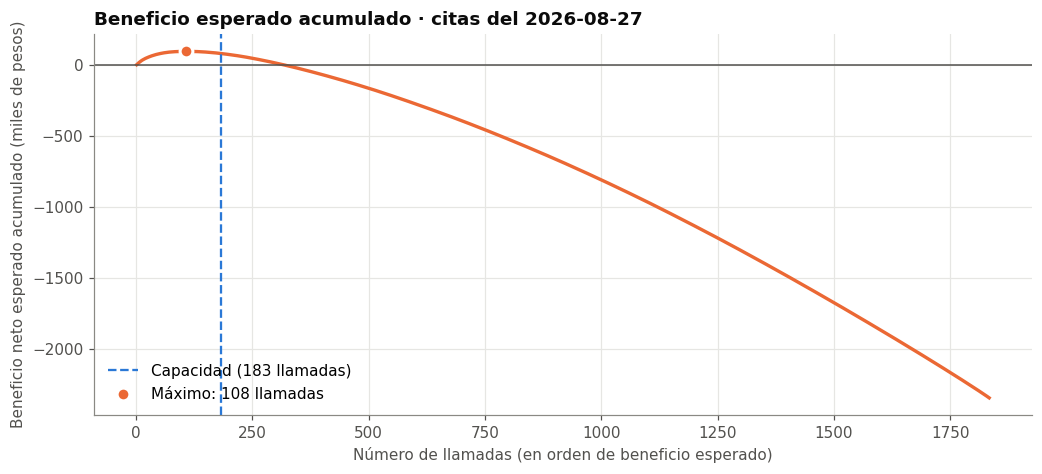

In [13]:
fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(manana["prioridad_financiera"], manana["beneficio_acumulado"] / 1e3, color=fm.NARANJA, linewidth=2.2)
ax.axvline(cupo_llamadas, color=fm.AZUL, linestyle="--", linewidth=1.5, label=f"Capacidad ({cupo_llamadas} llamadas)")
mejor = manana["beneficio_acumulado"].idxmax()
ax.scatter([manana.loc[mejor, "prioridad_financiera"]], [manana.loc[mejor, "beneficio_acumulado"] / 1e3], s=70, color=fm.NARANJA,
           edgecolor="white", linewidth=2, zorder=5, label=f"Máximo: {manana.loc[mejor, 'prioridad_financiera']} llamadas")
ax.axhline(0, color=fm.TINTA_SUAVE, linewidth=1)
ax.set_xlabel("Número de llamadas (en orden de beneficio esperado)")
ax.set_ylabel("Beneficio neto esperado acumulado (miles de pesos)")
ax.set_title(f"Beneficio esperado acumulado · citas del {FECHA_LLAMADAS}")
ax.legend(loc="lower left")
plt.show()

In [14]:
# ¿Cambia la lista al priorizar por impacto en vez de por riesgo?
top_riesgo = set(manana.nsmallest(cupo_llamadas, "prioridad")["cita_id"])
top_impacto = set(manana.nsmallest(cupo_llamadas, "prioridad_financiera")["cita_id"])
coinciden = len(top_riesgo & top_impacto)
print(f"De las {cupo_llamadas} llamadas, {coinciden} coinciden entre la lista por riesgo y la lista por impacto "
      f"({coinciden / max(cupo_llamadas, 1):.0%}). Diferencia: {cupo_llamadas - coinciden} citas.")

columnas = {"prioridad_financiera": "Prioridad financiera", "llamar": "Llamar", "prioridad": "Prioridad por riesgo",
            "nivel_riesgo": "Nivel de riesgo", "probabilidad_inasistencia": "Probabilidad de inasistencia",
            "valor_cupo": "Valor del cupo", "valor_esperado": "Valor esperado recuperado",
            "beneficio_esperado": "Beneficio neto esperado", "id_paciente": "ID paciente", "hora_cita": "Hora",
            "servicio_homologado": "Servicio", "sede": "Sede", "edad": "Edad", "motivos": "Motivos"}
lista = manana[list(columnas)].rename(columns=columnas)
lista.head(20).round(3)

De las 183 llamadas, 75 coinciden entre la lista por riesgo y la lista por impacto (41%). Diferencia: 108 citas.


,Prioridad financiera,Llamar,Prioridad por riesgo,Nivel de riesgo,Probabilidad de inasistencia,Valor del cupo,Valor esperado recuperado,Beneficio neto esperado,ID paciente,Hora,Servicio,Sede,Edad,Motivos
0,1,Sí,270,Medio,0.458,50000.0,5721.792,3221.792,1543599,7,ENDOCRINOLOGIA,CENTRO,22,"Faltó a su última cita; Niño, adolescente o jo..."
1,2,Sí,17,Alto,0.759,30000.0,5690.971,3190.971,1537773,11,GINECOLOGIA Y OBSTETRICIA,VILLAMARIA,20,Falta con frecuencia (13 de 19); Faltó a la úl...
2,3,Sí,24,Alto,0.736,30000.0,5521.577,3021.577,3153881,10,GINECOLOGIA Y OBSTETRICIA,LAURELES,26,Faltó a su última cita; Falta con frecuencia (...
3,4,Sí,25,Alto,0.734,30000.0,5505.314,3005.314,2348954,7,GINECOLOGIA Y OBSTETRICIA,LAURELES,46,Falta con frecuencia (13 de 16); Faltó a la úl...
4,5,Sí,13,Alto,0.783,28000.0,5481.261,2981.261,3640013,6,PEDIATRIA,LAURELES,3,Faltó a su última cita; Falta con frecuencia (...
5,6,Sí,14,Alto,0.780,28000.0,5461.614,2961.614,3255253,6,PEDIATRIA,CENTRO,3,Faltó a su última cita; Falta con frecuencia (...
6,7,Sí,385,Medio,0.415,50000.0,5184.471,2684.471,2261184,8,ENDOCRINOLOGIA,LAURELES,41,Falta con frecuencia (8 de 14); No pertenece a...
7,8,Sí,41,Alto,0.684,30000.0,5132.028,2632.028,2543024,11,PSIQUIATRIA,CENTRO,84,No pertenece a un programa de crónicos; Cita a...
8,9,Sí,49,Alto,0.666,30000.0,4998.191,2498.191,2741230,12,PSIQUIATRIA,CENTRO,41,No pertenece a un programa de crónicos; Cita a...
9,10,Sí,59,Alto,0.649,30000.0,4870.840,2370.840,1532918,8,PSIQUIATRIA,CENTRO,30,Faltó a su última cita; Falta con frecuencia (...


In [15]:
Path("salidas").mkdir(exist_ok=True)
ruta = Path("salidas") / f"llamadas_costo_efectividad_{FECHA_LLAMADAS}.xlsx"
resumen = pd.DataFrame({
    "Indicador": ["Fecha de las citas", "Citas evaluadas", "Capacidad de llamadas", "Llamadas recomendadas",
                  "Costo de las llamadas", "Valor esperado recuperado", "Beneficio neto esperado",
                  "Costo por llamada (supuesto)", "Efectividad general (supuesto)", "Valor general del cupo (supuesto)"],
    "Valor": [FECHA_LLAMADAS, len(manana), cupo_llamadas, len(llamar), pesos(len(llamar) * COSTO_LLAMADA),
              pesos(llamar["valor_esperado"].sum()), pesos(llamar["beneficio_esperado"].sum()),
              pesos(COSTO_LLAMADA), f"{EFECTIVIDAD_GENERAL:.0%}", pesos(VALOR_CUPO_GENERAL)],
})
with pd.ExcelWriter(ruta) as escritor:
    resumen.to_excel(escritor, sheet_name="Resumen", index=False)
    lista.round(3).to_excel(escritor, sheet_name="Lista priorizada", index=False)
print(f"Archivo generado: {ruta}")

Archivo generado: salidas/llamadas_costo_efectividad_2026-08-27.xlsx


In [16]:
# Solo para fechas pasadas: ¿qué habría pasado realmente con las llamadas recomendadas?
real, _ = pdiaria.evaluar_contra_realidad(manana.drop(columns=["servicio"], errors="ignore"), fuentes, paquete)
recomendadas = llamar.merge(real[["cita_id", "no_asiste"]], on="cita_id")
valor_real = (recomendadas["no_asiste"] * recomendadas["efectividad"] * recomendadas["valor_cupo"]).sum()
print(f"De las {len(recomendadas)} llamadas recomendadas, {recomendadas['no_asiste'].mean():.1%} eran pacientes que realmente iban a faltar.")
print(f"Beneficio neto realizado (con la efectividad supuesta): {pesos(valor_real - len(recomendadas) * COSTO_LLAMADA)}")

De las 108 llamadas recomendadas, 47.2% eran pacientes que realmente iban a faltar.
Beneficio neto realizado (con la efectividad supuesta): $87.675


## 9. ¿Qué precisión necesitaría el modelo para que las llamadas sean rentables?

Una llamada se paga sola cuando:

$$\text{precisión} \times \text{efectividad} \times \text{valor del cupo} \ \geq\ \text{costo de la llamada}$$

Es decir, la **precisión de equilibrio** es $\dfrac{\text{costo llamada}}{\text{efectividad} \times \text{valor del cupo}}$. Comparamos la precisión que logra hoy el modelo con la que haría falta, y calculamos el **techo teórico**: un modelo perfecto que solo llama a quienes realmente van a faltar.

In [17]:
def diagnostico_precision(capacidad, criterio):
    marca = seleccionar_llamadas(citas, capacidad, criterio)
    llamadas = citas[marca == 1]
    valor_medio = llamadas["valor_cupo"].mean()
    efectividad_media = llamadas["efectividad"].mean()
    precision_equilibrio = COSTO_LLAMADA / (efectividad_media * valor_medio)
    return {"capacidad": f"{capacidad:.0%}", "estrategia": criterio, "valor_medio_cupo_llamado": valor_medio,
            "precision_actual": llamadas["no_asiste"].mean(), "precision_equilibrio": precision_equilibrio,
            "brecha_pp": (llamadas["no_asiste"].mean() - precision_equilibrio) * 100}

diagnostico = pd.DataFrame([diagnostico_precision(c, e) for c in [CAPACIDAD_PRINCIPAL, CAPACIDAD_AMPLIADA]
                            for e in ["riesgo", "impacto"]])
vista = diagnostico.copy()
vista["valor_medio_cupo_llamado"] = vista["valor_medio_cupo_llamado"].apply(pesos)
vista["precision_actual"] = vista["precision_actual"].map("{:.1%}".format)
vista["precision_equilibrio"] = vista["precision_equilibrio"].map("{:.1%}".format)
vista["brecha_pp"] = vista["brecha_pp"].round(1)
vista

,capacidad,estrategia,valor_medio_cupo_llamado,precision_actual,precision_equilibrio,brecha_pp
0,10%,riesgo,$14.210,59.7%,70.4%,-10.6
1,10%,impacto,$28.596,42.9%,35.0%,7.9
2,30%,riesgo,$14.611,48.3%,68.4%,-20.2
3,30%,impacto,$22.256,41.4%,44.9%,-3.6


In [18]:
# Precisión de equilibrio por familia de servicio vs. precisión del modelo en el 10 % de mayor riesgo de esa familia
filas = []
for familia, grupo in citas.groupby("familia_servicio"):
    rango = grupo["p"].rank(ascending=False, pct=True)
    top = grupo[rango <= 0.10]
    valor_medio = grupo["valor_cupo"].mean()
    equilibrio = COSTO_LLAMADA / (grupo["efectividad"].mean() * valor_medio)
    filas.append({"familia": familia, "citas": len(grupo), "valor_medio_cupo": valor_medio,
                  "precision_equilibrio": equilibrio, "precision_modelo_top10": top["no_asiste"].mean(),
                  "rentable_hoy": "Sí" if top["no_asiste"].mean() >= equilibrio else "No"})
por_familia = pd.DataFrame(filas).sort_values("citas", ascending=False)
vista = por_familia.copy()
vista["valor_medio_cupo"] = vista["valor_medio_cupo"].apply(pesos)
vista["precision_equilibrio"] = vista["precision_equilibrio"].map(lambda v: f"{v:.0%}" if v <= 1 else f"{v:.0%} (imposible)")
vista["precision_modelo_top10"] = vista["precision_modelo_top10"].map("{:.1%}".format)
vista

,familia,citas,valor_medio_cupo,precision_equilibrio,precision_modelo_top10,rentable_hoy
3,Medicina general,16686,$14.493,69%,59.1%,No
0,Crónicos,8565,$14.450,69%,45.0%,No
5,Odontología,7103,$13.279,75%,67.3%,No
2,Especialista,5816,$33.911,29%,46.6%,Sí
7,Salud mental,3332,$15.810,63%,66.4%,Sí
1,Enfermería / PyP,1982,$5.000,200% (imposible),58.1%,No
4,Nutrición,1570,$12.500,80%,74.5%,No
6,Pediatría,1052,$28.000,36%,57.1%,Sí


In [19]:
# Techo teórico: modelo perfecto (solo llama a quienes realmente faltarán, priorizando por valor)
def resultado_oraculo(capacidad):
    puntaje = citas["no_asiste"] * citas["efectividad"] * citas["valor_cupo"] + np.random.default_rng(1).random(len(citas)) * 1e-6
    rango = puntaje.groupby(citas["fecha_cita"]).rank(method="first", ascending=False, pct=True)
    marca = ((rango <= capacidad) & (citas["no_asiste"] == 1)).astype(int)   # un modelo perfecto no llama a quien sí asistirá
    return resultado_financiero(citas, marca)

filas = []
for capacidad in [CAPACIDAD_PRINCIPAL, CAPACIDAD_AMPLIADA]:
    actual = estrategias.loc[(f"{capacidad:.0%}", "impacto")]
    oraculo = resultado_oraculo(capacidad)
    filas.append({"capacidad": f"{capacidad:.0%}", "beneficio_modelo_actual": pesos(actual["beneficio_neto"]),
                  "precision_modelo_actual": f"{actual['precision']:.1%}",
                  "beneficio_modelo_perfecto": pesos(oraculo["beneficio_neto"]), "ROI_modelo_perfecto": round(oraculo["ROI"], 2)})
pd.DataFrame(filas)

,capacidad,beneficio_modelo_actual,precision_modelo_actual,beneficio_modelo_perfecto,ROI_modelo_perfecto
0,10%,$448.300,42.9%,$13.531.125,1.18
1,30%,-$7.424.825,41.4%,$20.097.075,0.60


In [20]:
# Beneficio a capacidad principal (por impacto) si la precisión del modelo mejorara
# Supuesto de la aproximación: se hacen las mismas llamadas y cada punto de precisión adicional
# recupera valor en la misma proporción que hoy (se escala el valor realmente recuperado).
base = estrategias.loc[(f"{CAPACIDAD_PRINCIPAL:.0%}", "impacto")]
filas = []
for mejora_pp in [0, 5, 10, 15, 20]:
    precision = min(base["precision"] + mejora_pp / 100, 1)
    valor = base["valor_recuperado"] * precision / base["precision"]
    beneficio = valor - base["costo"]
    filas.append({"mejora de precisión": f"+{mejora_pp} pp", "precisión": f"{precision:.1%}",
                  "beneficio neto del periodo": pesos(beneficio), "ROI": round(beneficio / base["costo"], 2),
                  "proyección mensual": pesos(beneficio / dias * DIAS_ATENCION_MES)})
pd.DataFrame(filas)

,mejora de precisión,precisión,beneficio neto del periodo,ROI,proyección mensual
0,+0 pp,42.9%,$448.300,0.04,$336.225
1,+5 pp,47.9%,$1.840.081,0.16,$1.380.061
2,+10 pp,52.9%,$3.231.863,0.28,$2.423.897
3,+15 pp,57.9%,$4.623.644,0.40,$3.467.733
4,+20 pp,62.9%,$6.015.426,0.52,$4.511.569


## Resumen y siguientes pasos

- Este notebook **no cambia el modelo**; solo traduce sus probabilidades a decisiones de dinero.
- Las conclusiones son tan buenas como los supuestos. Prioridades para reducir la incertidumbre:
  1. **Valor del cupo por servicio:** diligenciar `costos_por_servicio.xlsx` con la tarifa contratada (o el valor que la IPS considere perdido).
  2. **Efectividad de la llamada:** medirla con un piloto controlado (citas de riesgo alto llamadas vs. no llamadas). Hoy es el supuesto que más mueve el resultado (sección 7).
  3. **Costo real de la llamada:** tiempo del agente × salario/hora + telefonía.
- Si el valor del cupo varía mucho entre servicios, conviene incorporar la **prioridad financiera** a la herramienta diaria (`prediccion_diaria.py`).